# Librerías

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import copy

# Definición de la red

In [2]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

# Dataset y Dataloader

In [4]:
class IrisDataset(Dataset):
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

In [5]:
full_iris_dataset = IrisDataset()
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_iris_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [6]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Ejercicio 1

Haz el entrenamiento de la red durante 100 epochs, reportando el loss de entrenamiento en cada epoch. Finalmente dibuja la gráfica del loss de entrenamiento a lo largo de las epochs.

In [33]:
from torch.cuda import device
num_epochs = 100
train_losses = []

epochs = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IrisMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for xB, yB in train_dataloader:
        xB, yB = xB.to(device), yB.to(device)

        optimizer.zero_grad()
        logits = model(xB)                # (batch, num_classes)
        loss = criterion(logits, yB)      # CrossEntropyLoss espera yB como clases (batch,)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xB.size(0)
        n_seen += xB.size(0)

    epochs.append(epoch)
    epoch_loss = running_loss / n_seen

    train_losses.append(epoch_loss)


    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xB, yB in test_dataloader:
            xB, yB = xB.to(device), yB.to(device)

            logits = model(xB)                  # (batch, num_classes)
            preds = torch.argmax(logits, dim=1) # dim=1 -> elegir clase
            correct += (preds == yB).sum().item()
            total += yB.size(0)

    test_acc = correct / total

    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f} | test_acc = {test_acc:.4f}")

Epoch 001 | train_loss = 1.1615 | test_acc = 0.2667
Epoch 002 | train_loss = 1.0494 | test_acc = 0.5000
Epoch 003 | train_loss = 0.9913 | test_acc = 0.8667
Epoch 004 | train_loss = 0.9487 | test_acc = 0.8667
Epoch 005 | train_loss = 0.9264 | test_acc = 0.8000
Epoch 006 | train_loss = 0.9058 | test_acc = 0.9000
Epoch 007 | train_loss = 0.8868 | test_acc = 0.9000
Epoch 008 | train_loss = 0.8658 | test_acc = 0.8667
Epoch 009 | train_loss = 0.8425 | test_acc = 0.8667
Epoch 010 | train_loss = 0.8219 | test_acc = 0.7333
Epoch 011 | train_loss = 0.8004 | test_acc = 0.7000
Epoch 012 | train_loss = 0.7785 | test_acc = 0.9000
Epoch 013 | train_loss = 0.7585 | test_acc = 0.9000
Epoch 014 | train_loss = 0.7416 | test_acc = 0.8667
Epoch 015 | train_loss = 0.7164 | test_acc = 0.8667
Epoch 016 | train_loss = 0.7021 | test_acc = 0.9000
Epoch 017 | train_loss = 0.6821 | test_acc = 0.9000
Epoch 018 | train_loss = 0.6644 | test_acc = 0.8667
Epoch 019 | train_loss = 0.6518 | test_acc = 0.7333
Epoch 020 | 

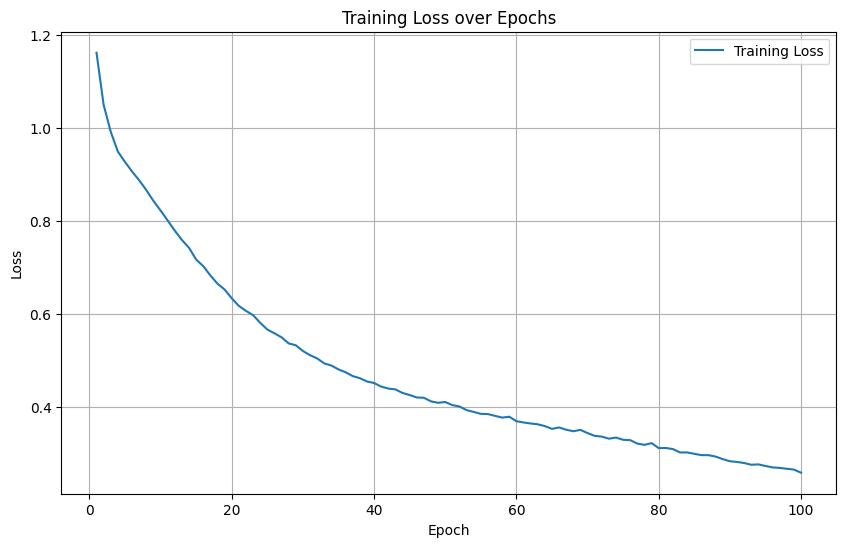

In [34]:
import matplotlib.pyplot as plt
import re

#
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Ejercicio 2

Antes de finalizar cada epoch, obtén el loss de validación. Haz otra gráfica que muestre ambos losses. Interpreta la gráfica.

In [35]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

num_epochs = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IrisMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = []
train_losses = []
val_losses = []
test_accs = []

for epoch in range(1, num_epochs + 1):

    # ---------------- TRAIN ----------------
    model.train()
    running_train_loss = 0.0
    n_train = 0

    for xB, yB in train_dataloader:
        xB = xB.to(device)
        yB = yB.to(device).long()   # 👈 importante para CrossEntropyLoss

        optimizer.zero_grad()
        logits = model(xB)
        loss = criterion(logits, yB)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xB.size(0)
        n_train += xB.size(0)

    train_loss = running_train_loss / n_train

    # ---------------- VAL (loss) ----------------
    model.eval()
    running_val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for xB, yB in val_dataloader:
            xB = xB.to(device)
            yB = yB.to(device).long()

            logits = model(xB)
            loss = criterion(logits, yB)

            running_val_loss += loss.item() * xB.size(0)
            n_val += yB.size(0)

    val_loss = running_val_loss / n_val

    # ---------------- TEST (accuracy) ----------------
    correct = 0
    total = 0

    with torch.no_grad():
        for xB, yB in test_dataloader:
            xB = xB.to(device)
            yB = yB.to(device).long()

            logits = model(xB)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yB).sum().item()
            total += yB.size(0)

    test_acc = correct / total

    # guardar métricas
    epochs.append(epoch)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:03d} | train_loss = {train_loss:.4f} | val_loss = {val_loss:.4f} | test_acc = {test_acc:.4f}")

# ---------------- PLOT: train vs val loss ----------------


Epoch 001 | train_loss = 1.0632 | val_loss = 1.1015 | test_acc = 0.3000
Epoch 002 | train_loss = 0.9999 | val_loss = 1.0235 | test_acc = 0.6667
Epoch 003 | train_loss = 0.9452 | val_loss = 0.9757 | test_acc = 0.7000
Epoch 004 | train_loss = 0.9083 | val_loss = 0.9467 | test_acc = 0.7333
Epoch 005 | train_loss = 0.8642 | val_loss = 0.9001 | test_acc = 0.7000
Epoch 006 | train_loss = 0.8296 | val_loss = 0.8855 | test_acc = 0.7333
Epoch 007 | train_loss = 0.7969 | val_loss = 0.8602 | test_acc = 0.8000
Epoch 008 | train_loss = 0.7632 | val_loss = 0.8190 | test_acc = 0.8000
Epoch 009 | train_loss = 0.7286 | val_loss = 0.7865 | test_acc = 0.8667
Epoch 010 | train_loss = 0.7037 | val_loss = 0.7895 | test_acc = 0.8000
Epoch 011 | train_loss = 0.6796 | val_loss = 0.7491 | test_acc = 0.8667
Epoch 012 | train_loss = 0.6570 | val_loss = 0.7394 | test_acc = 0.8667
Epoch 013 | train_loss = 0.6381 | val_loss = 0.7299 | test_acc = 0.9000
Epoch 014 | train_loss = 0.6190 | val_loss = 0.7075 | test_acc =

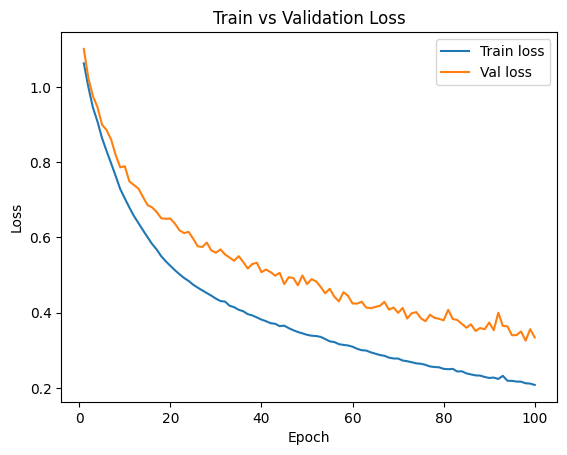

In [36]:
plt.figure()
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Ejercicio 3

Escoge una de estas dos opciones:
- Implementa early stopping con X epochs de paciencia.
- Implementa un mecanismo de guardar el mejor modelo y monitorización del loss de validación durante el entrenamiento.

**Nota.** Para guardar y restaurar el estado de la red:
```python
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
```

In [42]:
import copy
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs
        n += bs

    return running_loss / max(n, 1)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_hat = model(x)
        loss = criterion(y_hat, y)

        bs = x.size(0)
        running_loss += loss.item() * bs
        n += bs

    return running_loss / max(n, 1)

# --- Entrenamiento principal ---
best_val_loss = float("inf")
best_state = None
history = {"train_loss": [], "val_loss": []}

for epoch in range(num_epochs):
    train_losses = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
    val_loss   = evaluate(model, val_dataloader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        print(f"  Mejora detectada: {best_val_loss:.4f} → {val_loss:.4f}")
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best={best_val_loss:.4f}")

# Restaurar el mejor modelo
model.load_state_dict(best_state)

  Mejora detectada: inf → 0.2330
Epoch 1/100 | train_loss=0.2077 | val_loss=0.2330 | best=0.2330
  Mejora detectada: 0.2330 → 0.2221
Epoch 2/100 | train_loss=0.2077 | val_loss=0.2221 | best=0.2221
Epoch 3/100 | train_loss=0.2077 | val_loss=0.2469 | best=0.2221
Epoch 4/100 | train_loss=0.2077 | val_loss=0.2254 | best=0.2221
Epoch 5/100 | train_loss=0.2077 | val_loss=0.2287 | best=0.2221
Epoch 6/100 | train_loss=0.2077 | val_loss=0.2235 | best=0.2221
  Mejora detectada: 0.2221 → 0.2200
Epoch 7/100 | train_loss=0.2077 | val_loss=0.2200 | best=0.2200
  Mejora detectada: 0.2200 → 0.2184
Epoch 8/100 | train_loss=0.2077 | val_loss=0.2184 | best=0.2184
  Mejora detectada: 0.2184 → 0.2181
Epoch 9/100 | train_loss=0.2077 | val_loss=0.2181 | best=0.2181
Epoch 10/100 | train_loss=0.2077 | val_loss=0.2214 | best=0.2181
Epoch 11/100 | train_loss=0.2077 | val_loss=0.2186 | best=0.2181
Epoch 12/100 | train_loss=0.2077 | val_loss=0.2198 | best=0.2181
Epoch 13/100 | train_loss=0.2077 | val_loss=0.2204 |

<All keys matched successfully>

In [37]:
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)

<All keys matched successfully>

# Ejercicio 4

Evalúa la mejor red obtenida en el apartado anterior. Usa `accuracy` como métrica.

In [47]:
def evaluate_accuracy(loader, model, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Obtener clase predicha (índice del valor máximo)
            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [48]:
accuracyM = evaluate_accuracy(test_dataloader, model, device)
print(f"Accuracy en el conjunto de test: {accuracyM:.2f}%")

Accuracy en el conjunto de test: 93.33%


# Ejercicio 5

Aumenta la hidden dimension a 1024 e implementa algún método de regularización visto en clase ($L_1,L_2$ o dropout).
- [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [`weight_decay`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Para $L_1$ hay que hacerla a mano, añadiendo la norma $L_1$ de los parámetros al loss.
